## Лабораторная работа 1. Кластеризация



In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple

plt.style.use('seaborn-v0_8')

DATA_PATH = "Chemical Composion of Ceramic.csv"  

In [59]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print(df_raw.dtypes)
df_raw.head()

Shape: (88, 19)
Ceramic Name        str
Part                str
Na2O            float64
MgO             float64
Al2O3           float64
SiO2            float64
K2O             float64
CaO             float64
TiO2            float64
Fe2O3           float64
MnO               int64
CuO               int64
ZnO               int64
PbO2              int64
Rb2O              int64
SrO               int64
Y2O3              int64
ZrO2              int64
P2O5              int64
dtype: object


,Ceramic Name,Part,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
0,FLQ-1-b,Body,0.62,0.38,19.61,71.99,4.84,0.31,0.07,1.18,630,10,70,10,430,0,40,80,90
1,FLQ-2-b,Body,0.57,0.47,21.19,70.09,4.98,0.49,0.09,1.12,380,20,80,40,430,-10,40,100,110
2,FLQ-3-b,Body,0.49,0.19,18.60,74.70,3.47,0.43,0.06,1.07,420,20,50,50,380,40,40,80,200
3,FLQ-4-b,Body,0.89,0.30,18.01,74.19,4.01,0.27,0.09,1.23,460,20,70,60,380,10,40,70,210
4,FLQ-5-b,Body,0.03,0.36,18.41,73.99,4.33,0.65,0.05,1.19,380,40,90,40,360,10,30,80,150


### Выбор метрики качества кластеризации

Для данного датасета метки классов нам **неизвестны**, поэтому используем **внутреннюю метрику**, не требующую истинной разметки.

В качестве основной метрики будем использовать **силуэт (silhouette score)**:
- измеряет, насколько объект ближе к своему кластеру, чем к соседнему;
- даёт значения в диапазоне \([-1, 1]\);
- хорошо подходит для сравнения разных разбиений при различных `k` и гиперпараметрах.

Ниже реализуем вычисление среднего силуэта для произвольного разбиения на кластеры.

In [60]:
def pairwise_distances(X: np.ndarray) -> np.ndarray:
    """Матрица попарных евклидовых расстояний (n_samples, n_samples)."""
    sq_norms = np.sum(X ** 2, axis=1, keepdims=True)
    dists_sq = sq_norms + sq_norms.T - 2 * X @ X.T
    dists_sq = np.maximum(dists_sq, 0.0)
    return np.sqrt(dists_sq)


def silhouette_score(X: np.ndarray, labels: np.ndarray) -> float:
    """Средний силуэт по всем объектам (без sklearn).

    X: (n_samples, n_features)
    labels: (n_samples,) — метки кластеров (целые от 0 до k-1), шум можно исключить при вызове.
    """
    n = X.shape[0]
    D = pairwise_distances(X)
    unique_labels = np.unique(labels)
    k = len(unique_labels)
    if k <= 1:
        return 0.0

    sil_values = []
    for i in range(n):
        same_cluster = labels == labels[i]
        a_i = 0.0
        if np.sum(same_cluster) > 1:
            a_i = np.sum(D[i, same_cluster]) / (np.sum(same_cluster) - 1)

        b_i = np.inf
        for c in unique_labels:
            if c == labels[i]:
                continue
            mask_c = labels == c
            if np.any(mask_c):
                b_i = min(b_i, np.mean(D[i, mask_c]))

        if a_i < b_i and b_i > 0:
            s_i = 1.0 - a_i / b_i
        elif a_i > b_i and a_i > 0:
            s_i = b_i / a_i - 1.0
        else:
            s_i = 0.0
        sil_values.append(s_i)

    return float(np.mean(sil_values))

### Отбор признаков

1. Удалим неинформативные/идентификаторы (если есть).
2. Заполним пропуски (например, медианой по признаку).
3. Приведём признаки к одному масштабу (стандартизация до нулевого среднего и единичного СКО).

Дополнительно можно смотреть на:
- распределения признаков,
- матрицу корреляций и при желании убирать сильно скоррелированные признаки.

In [61]:
def preprocess_data(df: pd.DataFrame) -> Tuple[np.ndarray, pd.DataFrame]:
    """Предобработка и отбор признаков для кластеризации.

    Для датасета Ceramic Composition:
    - удаляем текстовые столбцы `Ceramic Name` и `Part`,
    - остальные столбцы принудительно переводим в числа,
    - заполняем пропуски медианой и масштабируем признаки.
    """
    df_proc = df.copy()

    # Удаляем явные категориальные признаки, если они есть
    for col in ["Ceramic Name", "Part"]:
        if col in df_proc.columns:
            df_proc = df_proc.drop(columns=[col])

    # Пробуем привести оставшиеся столбцы к числовому типу
    for col in df_proc.columns:
        df_proc[col] = pd.to_numeric(df_proc[col], errors="coerce")

    # Оставляем только числовые признаки
    df_proc = df_proc.select_dtypes(include=[np.number])

    # Заполнить пропуски медианой
    df_proc = df_proc.fillna(df_proc.median(numeric_only=True))

    # Стандартизация
    X = df_proc.values.astype(float)
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-8
    X_scaled = (X - mean) / std

    return X_scaled, df_proc


if df_raw is not None:
    X, df_proc = preprocess_data(df_raw)
    print("Shape after preprocessing:", X.shape)
else:
    X, df_proc = None, None

Shape after preprocessing: (88, 17)


### Реализация k-means++

Реализуем алгоритм кластеризации `k-means` с инициализацией центров по схеме `k-means++`:
- первый центр выбирается случайно;
- каждый следующий центр выбирается с вероятностью, пропорциональной квадрату расстояния до ближайшего уже выбранного центра;
- далее обычные итерации `k-means` до сходимости.

In [62]:
def kmeans_plusplus_init(X: np.ndarray, k: int, random_state: int | None = None) -> np.ndarray:
    """Инициализация центров по схеме k-means++."""
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]
    centers = [X[rng.integers(0, n_samples)].copy()]
    dists = np.linalg.norm(X - centers[0], axis=1)

    for _ in range(1, k):
        dists = np.minimum(dists, np.linalg.norm(X - centers[-1], axis=1))
        probs = dists ** 2
        probs_sum = probs.sum()
        if probs_sum <= 0:
            idx = rng.integers(0, n_samples)
        else:
            idx = rng.choice(n_samples, p=probs / probs_sum)
        centers.append(X[idx].copy())
    return np.array(centers)


def kmeans(X: np.ndarray, k: int, max_iter: int = 100, tol: float = 1e-4,
           random_state: int | None = None) -> Tuple[np.ndarray, np.ndarray]:
    """K-means с инициализацией k-means++. Возвращает (labels, centers)."""
    centers = kmeans_plusplus_init(X, k, random_state=random_state)
    n_samples = X.shape[0]

    for _ in range(max_iter):
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        new_centers = np.zeros_like(centers)
        for j in range(k):
            mask = labels == j
            if np.any(mask):
                new_centers[j] = X[mask].mean(axis=0)
            else:
                new_centers[j] = X[np.random.randint(0, n_samples)]
        if np.linalg.norm(new_centers - centers) < tol:
            break
        centers = new_centers
    return labels, centers

### Реализация DBSCAN

Реализуем простой вариант `DBSCAN`:
- строим \(\varepsilon\)-окрестности для каждой точки,
- помечаем core-точки (у которых не меньше `min_samples` соседей),
- запускаем поиск по графу плотности для формирования кластеров,
- оставшиеся точки считаем шумом (`label = -1`).

In [63]:
def dbscan(X: np.ndarray, eps: float, min_samples: int) -> np.ndarray:
    """DBSCAN: метки кластеров (шум = -1). Использует pairwise_distances."""
    n_samples = X.shape[0]
    D = pairwise_distances(X)
    neighbors = [np.where(D[i] <= eps)[0] for i in range(n_samples)]

    labels = np.full(n_samples, -1, dtype=int)
    visited = np.zeros(n_samples, dtype=bool)
    cluster_id = 0

    for i in range(n_samples):
        if visited[i]:
            continue
        visited[i] = True
        neigh = neighbors[i]
        if len(neigh) < min_samples:
            continue
        labels[i] = cluster_id
        seeds = list(neigh)
        j = 0
        while j < len(seeds):
            p = seeds[j]
            if not visited[p]:
                visited[p] = True
                if len(neighbors[p]) >= min_samples:
                    for q in neighbors[p]:
                        if q not in seeds:
                            seeds.append(q)
            if labels[p] == -1:
                labels[p] = cluster_id
            j += 1
        cluster_id += 1
    return labels

### Сравнение алгоритмов по силуету

Теперь запустим `k-means++` при разных значениях `k` и `DBSCAN` при разных параметрах `eps`,
посчитаем силуэт и сравним результаты.

k=2, silhouette=0.2860
k=3, silhouette=0.1961
k=4, silhouette=0.2008
k=5, silhouette=0.2275
k=6, silhouette=0.1915
k=7, silhouette=0.2209


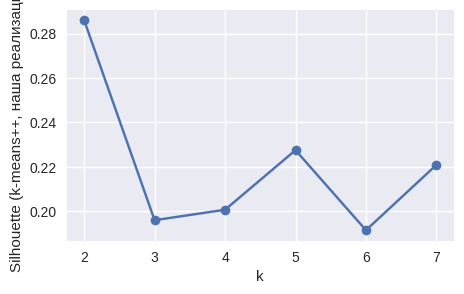

DBSCAN eps=0.50, silhouette=nan
DBSCAN eps=1.00, silhouette=nan
DBSCAN eps=1.50, silhouette=nan
DBSCAN eps=2.00, silhouette=nan
DBSCAN eps=2.50, silhouette=0.4205181386128992
DBSCAN eps=3.00, silhouette=0.3451946991065019


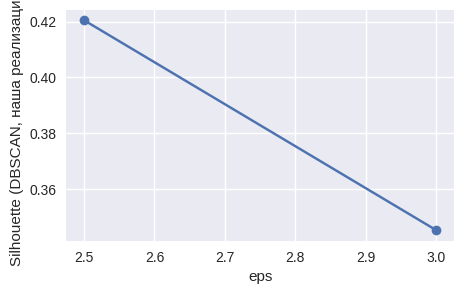

In [ ]:
if X is not None:
    # K-means++ и силуэт — реализации (без sklearn)
    ks = range(2, 8)
    sil_kmeans = []
    for k in ks:
        labels_k, _ = kmeans(X, k=k, random_state=42)
        sil = silhouette_score(X, labels_k)
        sil_kmeans.append(sil)
        print(f"k={k}, silhouette={sil:.4f}")

    plt.figure(figsize=(5, 3))
    plt.plot(list(ks), sil_kmeans, marker='o')
    plt.xlabel('k')
    plt.ylabel('Silhouette (k-means++, наша реализация)')
    plt.grid(True)
    plt.show()

    # DBSCAN и силуэт — реализации (без sklearn)
    eps_values = np.linspace(0.5, 3.0, 6)
    sil_db = []
    for eps in eps_values:
        labels_db = dbscan(X, eps=eps, min_samples=5)
        if len(np.unique(labels_db[labels_db != -1])) <= 1:
            sil = np.nan
        else:
            mask = labels_db != -1
            sil = silhouette_score(X[mask], labels_db[mask])
        sil_db.append(sil)
        print(f"DBSCAN eps={eps:.2f}, silhouette={sil}")

    plt.figure(figsize=(5, 3))
    plt.plot(eps_values, sil_db, marker='o')
    plt.xlabel('eps')
    plt.ylabel('Silhouette (DBSCAN, наша реализация)')
    plt.grid(True)
    plt.show()
else:
    print("Данные не загружены, сравнение алгоритмов не выполнено.")